In [2]:
# IMPORTS
import joblib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import time

from FuncionesAUX import *
from pathlib import Path
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.inspection import PartialDependenceDisplay
from scipy.spatial import cKDTree


In [3]:
# RUTAS DE TRABAJO
BASE = Path(r"C:\Users\Gambo\Documents\Master Aaron\TFM UCM")
DATA = BASE / "Data"
RUTA_MODELOS = Path("modelos")

ruta_dataset_maestro = DATA / "dataset_maestro.parquet"
ruta_civio = DATA / "CIVIO" / "fires-all.csv"

# CARGA INICIAL

In [4]:
# ============================================================
# CARGA Y COMPROBACIÓN INICIAL
# Carga el modelo definitivo (Random Forest) y los artefactos
# exportados desde 04_Model.ipynb, sin necesidad de reentrenar
# ni de tener 03/04 ejecutados en la misma sesión.
# ============================================================

# Modelo definitivo
modelo_rf_final = joblib.load(RUTA_MODELOS / "rf_final.joblib")

# Metadata (features, umbral, hiperparámetros, class_weight)
with open(RUTA_MODELOS / "rf_final_metadata.json", encoding="utf-8") as f:
    metadata_rf = json.load(f)

FEATURES_BASE = metadata_rf["features"]
TARGET = metadata_rf["target"]
umbral_rf_final = metadata_rf["umbral_decision"]

# Holdout de test (2021)
holdout_df_test = pd.read_parquet(RUTA_MODELOS / "holdout_test.parquet")
assert "latitude" in holdout_df_test.columns and "longitude" in holdout_df_test.columns

# Comparativa ligera de los otros 3 modelos
with open(RUTA_MODELOS / "comparativa_4_modelos.json", encoding="utf-8") as f:
    comparativa_4_modelos = json.load(f)

print_header("INTERPRETABILIDAD — CARGA INICIAL")
print(f"Modelo: {type(modelo_rf_final).__name__}")
print(f"Features ({len(FEATURES_BASE)}): {FEATURES_BASE}")
print(f"Target: {TARGET}")
print(f"Umbral de decisión (sin fuga, walk-forward): {umbral_rf_final:.4f}")
print(f"\nHoldout de test: {holdout_df_test.shape}")
print(f"Prevalencia holdout: {100*holdout_df_test[TARGET].mean():.4f}%")

INTERPRETABILIDAD — CARGA INICIAL
Modelo: RandomForestClassifier
Features (18): ['swvl1', 'swvl2', 't2m', 'tp', 'swi_T10_swvl1', 'swi_T10_swvl2', 'swi_T20_swvl1', 'swi_T20_swvl2', 'swi_T40_swvl1', 'swi_T40_swvl2', 'elevacion', 'pendiente', 'densidad_igniciones', 'pct_causa_antropica', 'pct_causa_rayo', 'dias_desde_inicio', 'mes_sin', 'mes_cos']
Target: target_incendio
Umbral de decisión (sin fuga, walk-forward): 0.5782

Holdout de test: (298205, 22)
Prevalencia holdout: 0.1335%


In [5]:
# ============================================================
# VERIFICACIÓN DE CONSISTENCIA
# Confirma que el modelo cargado predice de forma coherente con
# las métricas reportadas en 04 — detecta cualquier discrepancia
# entre lo exportado y lo que realmente se está cargando aquí
# (ej. si el .joblib quedó de una ejecución distinta a la del
# metadata.json, o si el holdout no coincide en tamaño/columnas).
# ============================================================

# Todas las features esperadas están en el holdout cargado
faltantes = set(FEATURES_BASE) - set(holdout_df_test.columns)
assert not faltantes, f"Faltan columnas en el holdout cargado: {faltantes}"

X_test = holdout_df_test[FEATURES_BASE]
y_test = holdout_df_test[TARGET]

proba_test_verificacion = modelo_rf_final.predict_proba(X_test)[:, 1]

pr_auc_verif = average_precision_score(y_test, proba_test_verificacion)
roc_auc_verif = roc_auc_score(y_test, proba_test_verificacion)

print_header("VERIFICACIÓN DE CONSISTENCIA — MODELO CARGADO vs 04")
print(f"PR-AUC  recalculado aquí : {pr_auc_verif:.4f}")
print(f"PR-AUC  reportado en 04  : {metadata_rf['metricas_holdout']['PR-AUC']:.4f}")
print(f"ROC-AUC recalculado aquí : {roc_auc_verif:.4f}")
print(f"ROC-AUC reportado en 04  : {metadata_rf['metricas_holdout']['ROC-AUC']:.4f}")

assert np.isclose(pr_auc_verif, metadata_rf["metricas_holdout"]["PR-AUC"], atol=1e-4), \
    "El PR-AUC recalculado no coincide con el reportado en 04 — revisar exportación"
assert np.isclose(roc_auc_verif, metadata_rf["metricas_holdout"]["ROC-AUC"], atol=1e-4), \
    "El ROC-AUC recalculado no coincide con el reportado en 04 — revisar exportación"

print("\nEl modelo cargado reproduce exactamente los resultados de 04_Model.ipynb")

VERIFICACIÓN DE CONSISTENCIA — MODELO CARGADO vs 04
PR-AUC  recalculado aquí : 0.0218
PR-AUC  reportado en 04  : 0.0218
ROC-AUC recalculado aquí : 0.9135
ROC-AUC reportado en 04  : 0.9135

El modelo cargado reproduce exactamente los resultados de 04_Model.ipynb


In [6]:
# ============================================================
# RESUMEN DE LO DISPONIBLE PARA EL RESTO DEL NOTEBOOK
# ============================================================
print_header("ARTEFACTOS DISPONIBLES PARA 05_INTERPRETABILIDAD")
print(f"modelo_rf_final       : {type(modelo_rf_final).__name__} entrenado (2008-2020)")
print(f"holdout_df_test       : {holdout_df_test.shape} (2021, nunca visto por el modelo)")
print(f"FEATURES_BASE         : {len(FEATURES_BASE)} variables")
print(f"umbral_rf_final       : {umbral_rf_final:.4f}")
print(f"comparativa_4_modelos : importancias + calibración de logística/RF/XGB/LightGBM")

ARTEFACTOS DISPONIBLES PARA 05_INTERPRETABILIDAD
modelo_rf_final       : RandomForestClassifier entrenado (2008-2020)
holdout_df_test       : (298205, 22) (2021, nunca visto por el modelo)
FEATURES_BASE         : 18 variables
umbral_rf_final       : 0.5782
comparativa_4_modelos : importancias + calibración de logística/RF/XGB/LightGBM


## Comparacion de importancia entre modelos

In [7]:
# ============================================================
# COMPARACIÓN DE IMPORTANCIAS ENTRE MODELOS
# Las importancias de XGBoost y LightGBM proceden de los
# artefactos exportados en 04_Model.ipynb.
# ============================================================

importancias_comparativas = comparativa_4_modelos["importancias"]
print_header("IMPORTANCIAS EXPORTADAS — MODELOS COMPARADOS")
for modelo, importancias in importancias_comparativas.items():
    print(f"\n{modelo.upper()}")
    serie = pd.Series(importancias).sort_values(ascending=False)
    display(serie.head(10).to_frame("Importancia"))

IMPORTANCIAS EXPORTADAS — MODELOS COMPARADOS

RF


,Importancia
densidad_igniciones,0.196701
dias_desde_inicio,0.122413
swvl1,0.077719
mes_cos,0.062840
swvl2,0.053584
pendiente,0.052947
t2m,0.047731
swi_T40_swvl2,0.044385
mes_sin,0.043147
swi_T10_swvl1,0.040704



XGB


,Importancia
densidad_igniciones,0.275802
swvl1,0.193494
dias_desde_inicio,0.108219
mes_sin,0.046777
pendiente,0.046675
mes_cos,0.043259
pct_causa_antropica,0.041830
swvl2,0.035971
swi_T40_swvl1,0.033299
swi_T40_swvl2,0.029215



LGBM_GAIN


,Importancia
densidad_igniciones,4.884658e+07
swvl1,2.451855e+07
dias_desde_inicio,2.450352e+07
pendiente,1.219299e+07
elevacion,1.185564e+07
mes_cos,1.067721e+07
pct_causa_antropica,6.738962e+06
swvl2,6.596809e+06
mes_sin,6.243282e+06
swi_T40_swvl2,4.607509e+06


In [8]:
# ============================================================
# TABLA COMPARATIVA DE IMPORTANCIAS
# ============================================================
df_importancias = pd.DataFrame({
    modelo: pd.Series(importancias)
    for modelo, importancias in importancias_comparativas.items()
})

df_importancias = df_importancias.fillna(0)

# Normalización para facilitar comparación entre modelos
df_importancias_norm = df_importancias.div(df_importancias.sum(axis=0), axis=1)
df_importancias_norm = (df_importancias_norm.sort_values("rf", ascending=False))
display(df_importancias_norm.round(4))

,rf,xgb,lgbm_gain
densidad_igniciones,0.1967,0.2758,0.2873
dias_desde_inicio,0.1224,0.1082,0.1441
swvl1,0.0777,0.1935,0.1442
mes_cos,0.0628,0.0433,0.0628
swvl2,0.0536,0.0360,0.0388
pendiente,0.0529,0.0467,0.0717
t2m,0.0477,0.0255,0.0174
swi_T40_swvl2,0.0444,0.0292,0.0271
mes_sin,0.0431,0.0468,0.0367
swi_T10_swvl1,0.0407,0.0165,0.0108


<Axes: title={'center': 'Importancia relativa de las principales variables'}>

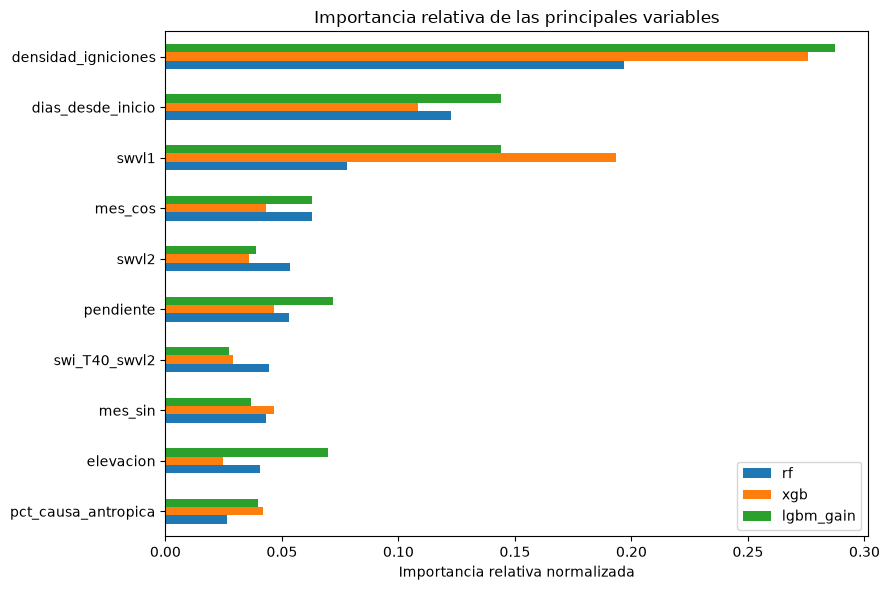

In [9]:
# ============================================================
# TOP 10 — COMPARACIÓN DE IMPORTANCIA RELATIVA
# ============================================================
top_variables = (
    df_importancias_norm
    .mean(axis=1)
    .sort_values(ascending=False)
    .head(10)
    .index
    )

display(
    df_importancias_norm.loc[top_variables]
    .sort_values("rf", ascending=True)
    .plot(
        kind="barh",
        figsize=(9, 6),
        title="Importancia relativa de las principales variables"
    ))

plt.xlabel("Importancia relativa normalizada")
plt.tight_layout()
plt.show()

Las importancias nativas muestran una señal parcialmente consistente entre los modelos de árboles, aunque con diferencias en la jerarquía de variables. Esta comparación se utiliza como primera aproximación descriptiva; no se interpreta como evidencia causal ni como medida definitiva de importancia, especialmente ante la presencia de variables climáticas correlacionadas.

Cabe destacar que las importancias nativas no son equivalentes entre modelos. RF, XGBoost y LightGBM no calculan exactamente la misma noción de "importancia". Por tanto, la figura sirve para: comparar patrones generales y detectar coherencias o discrepancias

# PREPARACIÓN DE MUESTRAS PARA INTERPRETABILIDAD

In [10]:
RANDOM_STATE_INTERP = 42
N_MUESTRA_GLOBAL = 20000

# Muestra global: mantiene aproximadamente la distribución real del holdout 2021.
muestra_global = holdout_df_test.sample(n=N_MUESTRA_GLOBAL, random_state=RANDOM_STATE_INTERP)

# Todos los positivos reales del holdout
muestra_positivos = holdout_df_test[holdout_df_test[TARGET] == 1].copy()

print_header("MUESTRAS DE INTERPRETABILIDAD")
print(f"Holdout completo       : {len(holdout_df_test):,}")
print(f"Muestra global         : {len(muestra_global):,}")
print(f"Positivos en muestra   : {muestra_global[TARGET].sum():,}")
print(f"Prevalencia muestra    : {muestra_global[TARGET].mean()*100:.4f}%")
print(f"\nPositivos completos    : {len(muestra_positivos):,}")

MUESTRAS DE INTERPRETABILIDAD
Holdout completo       : 298,205
Muestra global         : 20,000
Positivos en muestra   : 21
Prevalencia muestra    : 0.1050%

Positivos completos    : 398


# MODELO PROXY PARA SHAP

In [11]:
# ============================================================
# Exclusivamente para interpretación.
# El modelo definitivo continúa siendo el RF reportado en 04.
# ============================================================

modelo_rf_proxy = joblib.load(RUTA_MODELOS / "rf_proxy_shap.joblib")
with open(RUTA_MODELOS / "rf_proxy_validacion.json", encoding="utf-8") as f:
    validacion_proxy = json.load(f)

print_header("MODELO PROXY — CARGA")
print(f"Modelo definitivo : {type(modelo_rf_final).__name__}")
print(f"Modelo proxy      : {type(modelo_rf_proxy).__name__}")
print("\nFidelidad respecto al modelo definitivo:")
print(
    f"Correlación probabilidades : "
    f"{validacion_proxy['metricas_fidelidad']['correlacion_probabilidades']:.4f}")
print(
    f"Overlap Top-1%            : "
    f"{validacion_proxy['metricas_fidelidad']['overlap_top_1pct']:.4f}")
print(
    f"Overlap Top-5%            : "
    f"{validacion_proxy['metricas_fidelidad']['overlap_top_5pct']:.4f}")

MODELO PROXY — CARGA
Modelo definitivo : RandomForestClassifier
Modelo proxy      : RandomForestClassifier

Fidelidad respecto al modelo definitivo:
Correlación probabilidades : 0.9487
Overlap Top-1%            : 0.8645
Overlap Top-5%            : 0.8559


# SHAP

## Configuración y limitación computacional

El modelo definitivo (Random Forest, 300 árboles, max_depth=25) resultó computacionalmente inviable para el cálculo exacto de valores SHAP

Por ello, se utiliza en esta sección el modelo proxy desarrollado y validado (modelo_rf_proxy: 100 árboles, max_depth=16, min_samples_leaf=30). El modelo proxy **no sustituye** al modelo definitivo como resultado de rendimiento del TFM; se emplea exclusivamente como base de cálculo para SHAP.

In [12]:
# ============================================================
# SHAP — CONFIGURACIÓN DEL EXPLAINER
# feature_perturbation='tree_path_dependent': no requiere background,
# computacionalmente tratable dado el volumen de datos. Limitación
# reconocida: asume independencia entre features
# ============================================================

explainer_proxy = shap.TreeExplainer(modelo_rf_proxy, feature_perturbation="tree_path_dependent")
print_header("SHAP — CONFIGURACIÓN DEL EXPLAINER")
print(f"Modelo base: {type(modelo_rf_proxy).__name__} (proxy)")
print(f"  n_estimators = {modelo_rf_proxy.n_estimators}")
print(f"  max_depth    = {modelo_rf_proxy.max_depth}")
print(f"feature_perturbation: tree_path_dependent")

SHAP — CONFIGURACIÓN DEL EXPLAINER
Modelo base: RandomForestClassifier (proxy)
  n_estimators = 100
  max_depth    = 16
feature_perturbation: tree_path_dependent


Debido a la elevada complejidad computacional del modelo y a la imposibilidad práctica de utilizar feature_perturbation = "interventional" en el entorno disponible, se empleó tree_path_dependent. Este método permite el cálculo sobre el modelo proxy, pero debe interpretarse con cautela ante la correlación existente entre algunas variables derivadas del índice de humedad del suelo.

In [13]:
# ============================================================
# EXPECTED VALUE — verificación e interpretación
# El valor base de SHAP queda centrado en ≈0.5 por efecto de class_weight='balanced'
# aplicado durante el entrenamiento. Los valores SHAP deben interpretarse
# como desviaciones respecto a este punto de equilibrio artificial
# inducido por el balanceo de clases, no respecto al riesgo base real.
# ============================================================

expected_value_positivo = explainer_proxy.expected_value[1]

print_header("EXPECTED VALUE — CLASE POSITIVA")
print(f"expected_value (clase positiva): {expected_value_positivo:.6f}")
print(f"Prevalencia real del holdout 2021: {100*holdout_df_test[TARGET].mean():.2f}%")

EXPECTED VALUE — CLASE POSITIVA
expected_value (clase positiva): 0.499991
Prevalencia real del holdout 2021: 0.13%


El valor base del modelo proxy se sitúa aproximadamente en 0,5 en el espacio de salida utilizado por SHAP, por lo que no representa la prevalencia real de incendios del holdout.

Por tanto, los valores SHAP deben interpretarse como contribuciones respecto al valor base interno del modelo, no como desviaciones respecto a una probabilidad base del 0,13%.

## SHAP global (holdout 2021)

Se calcula SHAP sobre una muestra estratificada de 20.000 observaciones del holdout 2021, conservando la proporción real de positivos (prevalencia ≈0.13%). El objetivo es caracterizar el comportamiento
general del modelo sobre datos completamente no vistos durante el entrenamiento (dado el volumen de la muestra, los resultados reflejan mayoritariamente el tratamiento de los casos negativos)

In [14]:
# ============================================================
# SHAP GLOBAL — MUESTRA ESTRATIFICADA (n=20.000)
# ============================================================

N_MUESTRA_GLOBAL = 20000
RANDOM_STATE_INTERP = 42

muestra_global = holdout_df_test.sample(n=N_MUESTRA_GLOBAL, random_state=RANDOM_STATE_INTERP)
X_shap_global = muestra_global[FEATURES_BASE]

print_header("SHAP GLOBAL — MUESTRA")
print(f"Holdout completo    : {len(holdout_df_test):,}")
print(f"Muestra global      : {len(muestra_global):,}")
print(f"Positivos en muestra: {muestra_global[TARGET].sum():,}")
print(f"Prevalencia muestra : {100*muestra_global[TARGET].mean():.4f}%  "
      f"(holdout real: {100*holdout_df_test[TARGET].mean():.4f}%)")

SHAP GLOBAL — MUESTRA
Holdout completo    : 298,205
Muestra global      : 20,000
Positivos en muestra: 21
Prevalencia muestra : 0.1050%  (holdout real: 0.1335%)


In [15]:
# ============================================================
# SHAP GLOBAL — CÁLCULO (protegido contra recómputo accidental)
# Costo confirmado: ~219 min para n=20.000 con el modelo proxy.
# PROCESAR_SHAP=False carga el resultado ya guardado en disco;
# cambiar a True SOLO si se necesita recalcular deliberadamente
# ============================================================

PROCESAR_SHAP = False   # True = recalcula (~219 min)

ruta_shap_global = RUTA_MODELOS / "shap_global_positive_2D.npy"
ruta_muestra_global = RUTA_MODELOS / "muestra_global_shap.parquet"

if PROCESAR_SHAP or not ruta_shap_global.exists():
    print_header("SHAP GLOBAL — CALCULANDO (esto puede tardar ~3-4 horas)")
    t0 = time.time()
    shap_values_global_raw = explainer_proxy.shap_values(X_shap_global)
    tiempo_shap_global = time.time() - t0
    print(f"Tiempo: {tiempo_shap_global/60:.2f} min")

    # Indexado a clase positiva (verificado: viene como array 3D (n, features, clases))
    if isinstance(shap_values_global_raw, list):
        shap_global_positive = shap_values_global_raw[1]
    elif np.ndim(shap_values_global_raw) == 3:
        shap_global_positive = shap_values_global_raw[:, :, 1]
    else:
        shap_global_positive = shap_values_global_raw

    assert shap_global_positive.shape == (len(X_shap_global), len(FEATURES_BASE)), \
        f"Shape incorrecto: {shap_global_positive.shape}"

    # Guardado inmediato — no perder el cómputo
    np.save(ruta_shap_global, shap_global_positive)
    muestra_global.to_parquet(ruta_muestra_global, index=False)
    print(f"Guardado en {ruta_shap_global}")

else:
    print_header("SHAP GLOBAL — CARGANDO DESDE DISCO (ya calculado)")
    shap_global_positive = np.load(ruta_shap_global)
    muestra_global = pd.read_parquet(ruta_muestra_global)
    X_shap_global = muestra_global[FEATURES_BASE]
    print(f"Cargado: {shap_global_positive.shape} desde {ruta_shap_global}")

assert shap_global_positive.shape == (len(X_shap_global), len(FEATURES_BASE)), \
    "Verificación final de forma falló — revisar antes de graficar"
print(f"\nListo para graficar: shap_global_positive {shap_global_positive.shape}")

SHAP GLOBAL — CARGANDO DESDE DISCO (ya calculado)
Cargado: (20000, 18) desde modelos\shap_global_positive_2D.npy

Listo para graficar: shap_global_positive (20000, 18)


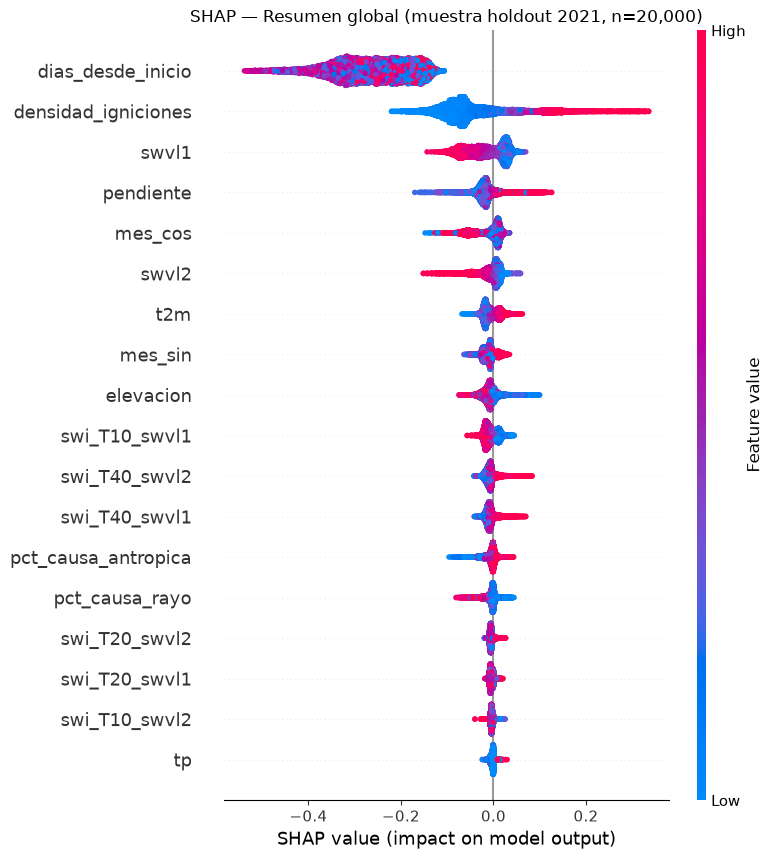

In [16]:
# ============================================================
# SHAP GLOBAL — SUMMARY PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(14, 8))
shap.summary_plot(shap_global_positive, X_shap_global, feature_names=FEATURES_BASE, show=False, max_display=18)
plt.title(f"SHAP — Resumen global (muestra holdout 2021, n={len(muestra_global):,})")
plt.tight_layout()
save_figure("shap_summary_global.png")
plt.show()

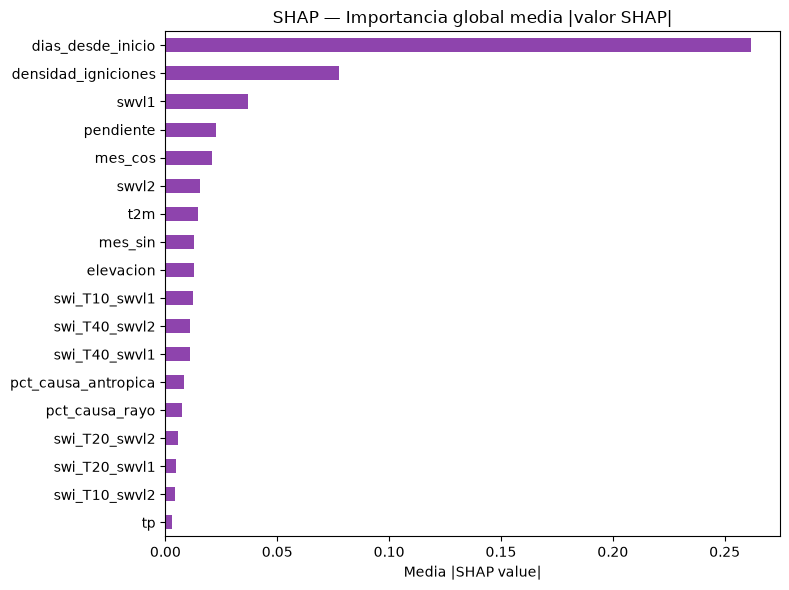

SHAP GLOBAL — TOP 5 VARIABLES
dias_desde_inicio      0.261650
densidad_igniciones    0.077798
swvl1                  0.037009
pendiente              0.022629
mes_cos                0.021044
dtype: float64


In [17]:
# ============================================================
# SHAP GLOBAL — BAR PLOT (importancia bruta)
# ============================================================

importancia_shap_global = pd.Series(
    np.abs(shap_global_positive).mean(axis=0), index=FEATURES_BASE).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
importancia_shap_global.plot(kind="barh", ax=ax, color="#8e44ad")
ax.invert_yaxis()
ax.set_title("SHAP — Importancia global media |valor SHAP|")
ax.set_xlabel("Media |SHAP value|")
plt.tight_layout()
save_figure("shap_bar_global.png")
plt.show()

print_header("SHAP GLOBAL — TOP 5 VARIABLES")
print(importancia_shap_global.head(5))

**OBSERVACIÓN**: dias_desde_inicio domina en magnitud media (0.262), muy por encima de la siguiente variable (densidad_igniciones, 0.078). Antes de interpretar esto como una relación temporal aprendida por el modelo, se investiga si este efecto refleja señal genuina o un artefacto de extrapolación — dado que todo el holdout 2021 cae fuera del rango de valores de esta variable observado durante el entrenamiento (2008-2020).

## SHAP incendios reales (n=398)

A diferencia de la muestra global, aquí no se busca representar la distribución del holdout, sino estudiar  específicamente qué variables intervienen en las predicciones asociadas a los 398 incendios realmente observados en 2021 — la pregunta que más interesa desde el punto de vista aplicado del sistema de alerta temprana.

In [18]:
# ============================================================
# SHAP POSITIVOS — MUESTRA (los 398 incendios reales completos)
# ============================================================

muestra_positivos = holdout_df_test[holdout_df_test[TARGET] == 1].copy()
X_shap_positivos = muestra_positivos[FEATURES_BASE]

print_header("SHAP POSITIVOS — MUESTRA")
print(f"Incendios reales en el holdout 2021: {len(muestra_positivos):,}")

SHAP POSITIVOS — MUESTRA
Incendios reales en el holdout 2021: 398


In [19]:
# ============================================================
# SHAP POSITIVOS — CÁLCULO (protegido contra recómputo accidental)
# Costo confirmado: ~3 min para n=398 con el modelo proxy.
# ============================================================

PROCESAR_SHAP_POSITIVOS = False   # True = recalcula (~3 min)

ruta_shap_positivos = RUTA_MODELOS / "shap_positive_cases.npy"
ruta_muestra_positivos = RUTA_MODELOS / "muestra_positivos_shap.parquet"

if PROCESAR_SHAP_POSITIVOS or not ruta_shap_positivos.exists():
    print_header("SHAP POSITIVOS — CALCULANDO")
    t0 = time.time()
    shap_values_positivos_raw = explainer_proxy.shap_values(X_shap_positivos)
    tiempo_shap_positivos = time.time() - t0
    print(f"Tiempo: {tiempo_shap_positivos/60:.2f} min")

    if isinstance(shap_values_positivos_raw, list):
        shap_positive_cases = shap_values_positivos_raw[1]
    elif np.ndim(shap_values_positivos_raw) == 3:
        shap_positive_cases = shap_values_positivos_raw[:, :, 1]
    else:
        shap_positive_cases = shap_values_positivos_raw

    assert shap_positive_cases.shape == (len(X_shap_positivos), len(FEATURES_BASE)), \
        f"Shape incorrecto: {shap_positive_cases.shape}"

    np.save(ruta_shap_positivos, shap_positive_cases)
    muestra_positivos.to_parquet(ruta_muestra_positivos, index=False)
    print(f"Guardado en {ruta_shap_positivos}")

else:
    print_header("SHAP POSITIVOS — CARGANDO DESDE DISCO (ya calculado)")
    shap_positive_cases = np.load(ruta_shap_positivos)
    muestra_positivos = pd.read_parquet(ruta_muestra_positivos)
    X_shap_positivos = muestra_positivos[FEATURES_BASE]
    print(f"Cargado: {shap_positive_cases.shape} desde {ruta_shap_positivos}")

assert shap_positive_cases.shape == (len(X_shap_positivos), len(FEATURES_BASE)), \
    "Verificación final de forma falló — revisar antes de graficar"
print(f"\nListo para graficar: shap_positive_cases {shap_positive_cases.shape}")

SHAP POSITIVOS — CARGANDO DESDE DISCO (ya calculado)
Cargado: (398, 18) desde modelos\shap_positive_cases.npy

Listo para graficar: shap_positive_cases (398, 18)


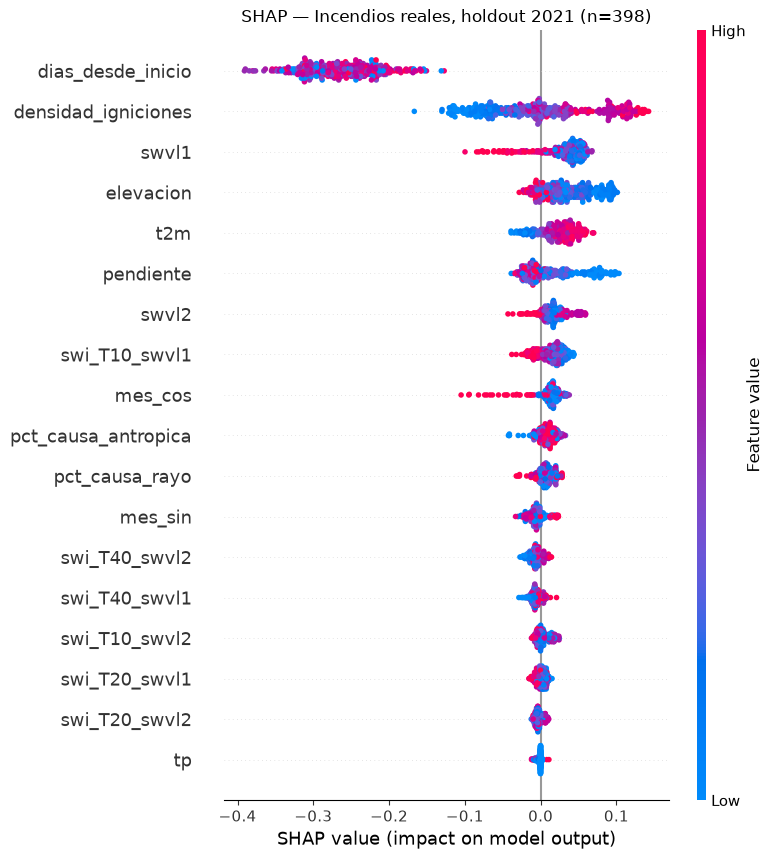

In [52]:
# ============================================================
# SHAP POSITIVOS — SUMMARY PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))
shap.summary_plot(
    shap_positive_cases, X_shap_positivos,
    feature_names=FEATURES_BASE, show=False, max_display=18
)
plt.title(f"SHAP — Incendios reales, holdout 2021 (n={len(muestra_positivos)})")
plt.tight_layout()
save_figure("shap_summary_positivos.png")
plt.show()

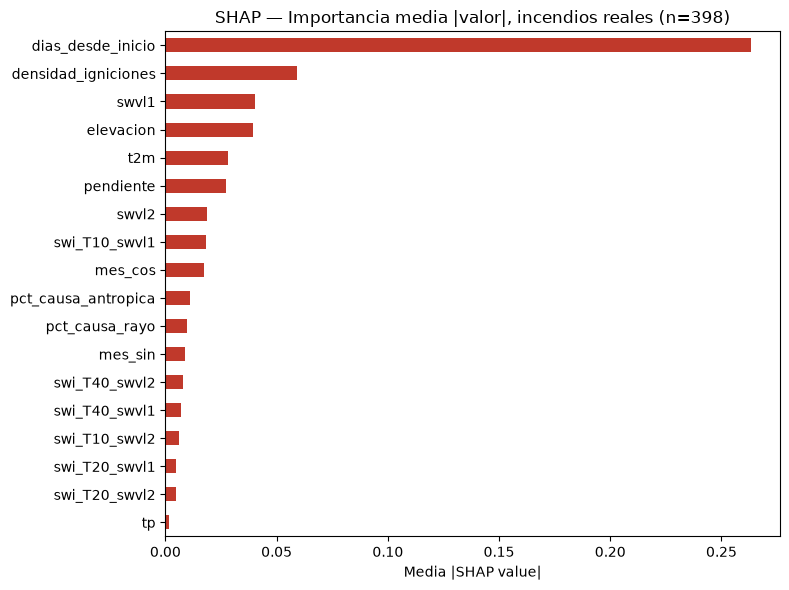

SHAP POSITIVOS — TOP 5 VARIABLES
dias_desde_inicio      0.263150
densidad_igniciones    0.058998
swvl1                  0.040342
elevacion              0.039235
t2m                    0.028088
dtype: float64
COMPARACIÓN DE RANKINGS — GLOBAL vs POSITIVOS


,Ranking Global,Ranking Positivos
dias_desde_inicio,1,1
densidad_igniciones,2,2
swvl1,3,3
elevacion,9,4
t2m,7,5
pendiente,4,6
swvl2,6,7
swi_T10_swvl1,10,8
mes_cos,5,9
pct_causa_antropica,13,10


In [21]:
# ============================================================
# SHAP POSITIVOS — BAR PLOT + COMPARACIÓN DE RANKINGS
# ============================================================

importancia_shap_positivos = pd.Series(
    np.abs(shap_positive_cases).mean(axis=0), index=FEATURES_BASE).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
importancia_shap_positivos.plot(kind="barh", ax=ax, color="#c0392b")
ax.invert_yaxis()
ax.set_title(f"SHAP — Importancia media |valor|, incendios reales (n={len(muestra_positivos)})")
ax.set_xlabel("Media |SHAP value|")
plt.tight_layout()
save_figure("shap_bar_positivos.png")
plt.show()

print_header("SHAP POSITIVOS — TOP 5 VARIABLES")
print(importancia_shap_positivos.head(5))

comparacion_rankings = pd.DataFrame({
    "Ranking Global": importancia_shap_global.rank(ascending=False).astype(int),
    "Ranking Positivos": importancia_shap_positivos.rank(ascending=False).astype(int),
}).sort_values("Ranking Positivos")

print_header("COMPARACIÓN DE RANKINGS — GLOBAL vs POSITIVOS")
display(comparacion_rankings)

In [22]:
# ============================================================
# DIAGNÓSTICO — correlación valor-SHAP en positivos
# ============================================================

print_header("CORRELACIÓN VALOR-SHAP — SOLO POSITIVOS (n=398)")
for var in ["dias_desde_inicio", "densidad_igniciones", "swvl1", "pendiente", "mes_cos"]:
    idx = FEATURES_BASE.index(var)
    shap_var = shap_positive_cases[:, idx]
    valor_var = X_shap_positivos[var].values
    corr = np.corrcoef(valor_var, shap_var)[0, 1]
    print(f"{var:22s}: correlación = {corr:.4f}  (SHAP medio = {shap_var.mean():.4f}, std = {shap_var.std():.4f})")

CORRELACIÓN VALOR-SHAP — SOLO POSITIVOS (n=398)
dias_desde_inicio     : correlación = 0.1537  (SHAP medio = -0.2632, std = 0.0476)
densidad_igniciones   : correlación = 0.8575  (SHAP medio = -0.0020, std = 0.0717)
swvl1                 : correlación = -0.7275  (SHAP medio = 0.0312, std = 0.0298)
pendiente             : correlación = -0.6359  (SHAP medio = 0.0129, std = 0.0348)
mes_cos               : correlación = -0.5414  (SHAP medio = 0.0119, std = 0.0176)


% con SHAP > 0: 44.0%  |  % con SHAP < 0: 56.0%


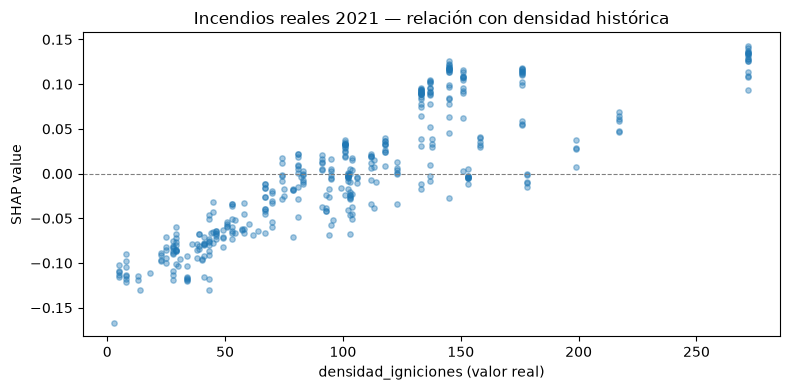

In [23]:
# ============================================================
# VERIFICACIÓN — ¿se distribuyen los positivos a lo largo de
# todo el rango de densidad_igniciones?
# ============================================================

idx_dens = FEATURES_BASE.index("densidad_igniciones")
shap_dens_pos = shap_positive_cases[:, idx_dens]
valor_dens_pos = X_shap_positivos["densidad_igniciones"].values

print(f"% con SHAP > 0: {100*(shap_dens_pos > 0).mean():.1f}%  |  "
      f"% con SHAP < 0: {100*(shap_dens_pos < 0).mean():.1f}%")

fig, ax = plt.subplots(figsize=(8,4))
ax.scatter(valor_dens_pos, shap_dens_pos, alpha=0.4, s=15)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("densidad_igniciones (valor real)")
ax.set_ylabel("SHAP value")
ax.set_title("Incendios reales 2021 — relación con densidad histórica")
plt.tight_layout()
save_figure("shap_densidad_positivos.png")
plt.show()

**OBSERVACIÓN**: el patrón de dias_desde_inicio se replica en los incendios reales. densidad_igniciones muestra una relación prácticamente lineal con su SHAP value (correlación=0.86); su SHAP medio cercano a cero se explica por el reparto de los 398 positivos a lo largo de todo el rango de la variable y no por falta de señal. swvl1 mantiene una correlación fuerte y negativa (-0.73) con SHAP medio positivo (+0.031), reforzando directamente la hipótesis central del TFM sobre el papel del déficit hídrico

## Verificación — dias_desde_inicio y extrapolación

Tanto en el SHAP global como en incendios reales dias_desde_inicio presenta la mayor magnitud media de SHAP, pese a una correlación prácticamente nula entre su valor real y su efecto SHAP. A continuación se realiza aquí una verificación directa en dos pasos: (1) comparar el rango de la variable en 2021 contra los umbrales de decisión aprendidos por los árboles, y (2) una prueba de invariancia que modifica artificialmente la variable y observa si la predicción cambia.

A diferencia del análisis SHAP, esta verificación se realiza directamente sobre el modelo definitvo o final, dado que la extracción de umbrales de árbol y el test de intervención son operaciones computacionalmente economicas que no requieren simplificación.

In [24]:
# ============================================================
# VERIFICACIÓN DEFINITIVA — dias_desde_inicio Y EXTRAPOLACIÓN
# Paso 1: rango de la variable en 2021 vs umbrales aprendidos
# Realizado sobre modelo_rf_final (el definitivo), no el proxy.
# ============================================================

print_header("VERIFICACIÓN DEFINITIVA — dias_desde_inicio Y EXTRAPOLACIÓN")

dias_test = holdout_df_test["dias_desde_inicio"]

print("Rango en holdout 2021:")
print(f"  Mínimo : {dias_test.min():.0f}")
print(f"  Máximo : {dias_test.max():.0f}")
print(f"  Únicos : {dias_test.nunique():,}")

idx_dias = FEATURES_BASE.index("dias_desde_inicio")
umbrales_dias = []

for arbol in modelo_rf_final.estimators_:
    threshold = arbol.tree_.threshold[idx_dias]
    threshold = threshold[threshold != -2]
    if len(threshold) > 0:
        umbrales_dias.extend(threshold)

umbrales_dias = np.asarray(umbrales_dias)

print("\nUmbrales utilizados por los árboles para dias_desde_inicio:")
if len(umbrales_dias) == 0:
    print("  La variable no aparece en ningún split.")
else:
    print(f"  Número de splits : {len(umbrales_dias):,}")
    print(f"  Mínimo           : {umbrales_dias.min():.2f}")
    print(f"  Máximo           : {umbrales_dias.max():.2f}")

if len(umbrales_dias) > 0:
    fuera_rango = dias_test > umbrales_dias.max()
    print(f"\nObservaciones 2021 por encima del mayor umbral del modelo: "
          f"{fuera_rango.mean()*100:.2f}%")
    if fuera_rango.all():
        print("\nTodo el holdout 2021 está fuera del rango de splits aprendido.")
    else:
        print("\nExisten observaciones de 2021 dentro del rango de splits aprendido.")

VERIFICACIÓN DEFINITIVA — dias_desde_inicio Y EXTRAPOLACIÓN
Rango en holdout 2021:
  Mínimo : 4749
  Máximo : 5113
  Únicos : 365

Umbrales utilizados por los árboles para dias_desde_inicio:
  Número de splits : 183
  Mínimo           : -1.00
  Máximo           : 3499.50

Observaciones 2021 por encima del mayor umbral del modelo: 100.00%

Todo el holdout 2021 está fuera del rango de splits aprendido.


In [25]:
# ============================================================
# PRUEBA DE INVARIANCIA
# Paso 2: se modifica artificialmente dias_desde_inicio en 1.000
# observaciones del holdout, manteniendo el resto constante, y se
# comprueba si la predicción del modelo definitivo cambia.
# ============================================================

n_prueba = 1000
X_prueba = X_test.sample(n=n_prueba, random_state=42).copy()

valores_dias = [
    X_prueba["dias_desde_inicio"].min(),
    X_prueba["dias_desde_inicio"].median(),
    X_prueba["dias_desde_inicio"].max(),
    X_prueba["dias_desde_inicio"].max() * 3,   # escenario extremo adicional
]

predicciones = []
for valor in valores_dias:
    X_modificado = X_prueba.copy()
    X_modificado["dias_desde_inicio"] = valor
    proba = modelo_rf_final.predict_proba(X_modificado[FEATURES_BASE])[:, 1]
    predicciones.append(proba)

predicciones = np.asarray(predicciones)
diferencias = np.ptp(predicciones, axis=0)

print_header("PRUEBA DE INVARIANCIA — dias_desde_inicio")
print(f"Escenarios probados: min, mediana, max, max×3 = {[f'{v:.0f}' for v in valores_dias]}")
print(f"Máxima diferencia de probabilidad entre escenarios: {diferencias.max():.10f}")
print(f"Diferencia media absoluta: {np.mean(diferencias):.10f}")
print(f"Observaciones con cambio > 1e-10: {np.sum(diferencias > 1e-10):,} / {n_prueba}")

PRUEBA DE INVARIANCIA — dias_desde_inicio
Escenarios probados: min, mediana, max, max×3 = ['4749', '4937', '5113', '15339']
Máxima diferencia de probabilidad entre escenarios: 0.0000000000
Diferencia media absoluta: 0.0000000000
Observaciones con cambio > 1e-10: 0 / 1000


El 100% de las observaciones de 2021 se sitúan por encima del umbral máximo aprendido por cualquier árbol del modelo
(umbral máximo = 3.499,5; rango del holdout = 4.749 – 5.113). La prueba de invariancia confirma, con diferencia exactamente nula en las 1.000 observaciones evaluadas, que modificar dias_desde_inicio dentro del rango de 2021 no altera en absoluto la predicción del modelo

dias_desde_inicio` presenta la mayor magnitud media de SHAP, pero su efecto no representa una relación temporal aprendida dentro de 2021. La prueba de invariancia confirma que modificar esta variable dentro del rango de 2021 no altera en absoluto las predicciones del modelo. Por tanto, su elevada contribución SHAP debe interpretarse como consecuencia del mecanismo de extrapolación de los modelos basados en árboles ante valores fuera de rango, y no como evidencia de una gradación temporal del riesgo aprendida a lo largo de 2021.

El análisis SHAP del modelo proxy —utilizado para aproximar el comportamiento del Random Forest definitivo, dada la inviabilidad computacional de calcular SHAP exacto sobre este último (sección anterior)— permite identificar las 
variables que más contribuyen a las predicciones y analizar la dirección de dichas contribuciones. Los resultados muestran una contribución relevante de la densidad histórica de igniciones, la humedad del suelo, la pendiente y la 
estacionalidad.

Se ha identificado además un efecto específico asociado a dias_desde_inicio, cuya elevada importancia global responde principalmente a la extrapolación temporal del modelo fuera del rango utilizado durante el entrenamiento. Este 
efecto no presenta capacidad discriminativa dentro de 2021 y, por tanto, se excluye del ranking utilizado para interpretar las variables que diferencian el riesgo relativo dentro del año evaluado.

En conjunto, los resultados proporcionan evidencia interpretable y físicamente coherente sobre los principales factores asociados por el modelo proxy al riesgo de incendio, coherente con el comportamiento del modelo definitivo según los indicadores de fidelidad reportados en la sección "Modelo proxy para SHAP".

# PDP - Partial Dependence Plots

En este trabajo, los PDP complementan el análisis SHAP realizado anteriormente. Mientras SHAP permite cuantificar la contribución de cada variable a las predicciones individuales, los PDP permiten visualizar la relación promedio aprendida por el modelo entre una variable y su salida.

El objetivo no es establecer relaciones causales, sino identificar patrones sistemáticos aprendidos por el Random Forest y comprobar su coherencia con los resultados obtenidos mediante SHAP y con el conocimiento físico del problema.

In [26]:
# ============================================================
# PDP — MUESTRA DE ANÁLISIS
# Se reutiliza la misma muestra que SHAP global, para
# comparabilidad directa entre métodos (sección 6.6).
# ============================================================

muestra_pdp = pd.read_parquet(RUTA_MODELOS / "muestra_global_shap.parquet")

X_pdp = muestra_pdp[FEATURES_BASE].copy()
y_pdp = muestra_pdp[TARGET].copy()

print_header("PDP — MUESTRA DE ANÁLISIS")
print(f"Observaciones : {len(X_pdp):,}")
print(f"Variables     : {X_pdp.shape[1]}")
print(f"Prevalencia   : {100*y_pdp.mean():.4f}%")

assert set(FEATURES_BASE).issubset(X_pdp.columns), \
    "La muestra PDP no contiene todas las variables del modelo."
print("La muestra contiene todas las variables del modelo.")

PDP — MUESTRA DE ANÁLISIS
Observaciones : 20,000
Variables     : 18
Prevalencia   : 0.1050%
La muestra contiene todas las variables del modelo.


## Seleccion de Variables

In [27]:
# ============================================================
# PDP — SELECCIÓN DE VARIABLES
# Se excluye dias_desde_inicio porque el análisis SHAP mostró
# que su elevada importancia está asociada a un desplazamiento
# prácticamente constante por extrapolación temporal.
# ============================================================

importancia_shap_efectiva = (importancia_shap_global.drop("dias_desde_inicio").sort_values(ascending=False))
top_variables_shap = importancia_shap_efectiva.head(4).index.tolist()
variables_pdp = top_variables_shap + ["swvl2", "dias_desde_inicio"]

print_header("PDP — VARIABLES SELECCIONADAS")

print("Variables principales según SHAP efectivo:")
for i, v in enumerate(top_variables_shap, 1):
    print(f"  {i}. {v}")

print("\nVariable de contexto por colinealidad:")
print("  5. swvl2")

print("\nVariable de contraste por extrapolación:")
print("  6. dias_desde_inicio")

PDP — VARIABLES SELECCIONADAS
Variables principales según SHAP efectivo:
  1. densidad_igniciones
  2. swvl1
  3. pendiente
  4. mes_cos

Variable de contexto por colinealidad:
  5. swvl2

Variable de contraste por extrapolación:
  6. dias_desde_inicio


## Consideraciones metodológicas

**1. class_weight='balanced'**: al igual que se documentó para la calibración del modelo en el capítulo de modelado, el eje Y representa la salida media del modelo para la clase positiva y no debe interpretarse directamente como una probabilidad calibrada de incendio.

**2. Colinealidad entre variables SWI**: swvl1 y swvl2 están fuertemente correlacionadas. El PDP asume independencia entre la variable analizada y el resto — con variables correlacionadas, el gráfico puede mostrar combinaciones de
valores poco realistas o infrecuentes en los datos reales, lo que puede distorsionar la forma de la curva.

**3. dias_desde_inicio y extrapolación**: se incluye deliberadamente en el análisis pese a estar demostrado como artefacto.

In [28]:
# ============================================================
# FIX — convertir todas las features a float antes de PDP
# densidad_igniciones (int32) causa el error de 'brute'; se
# convierte X_pdp completo a float64, sin alterar los valores.
# ============================================================

X_pdp = X_pdp.astype(np.float64)

print_header("VERIFICACIÓN DE TIPOS — X_pdp")
print(X_pdp.dtypes.value_counts())
assert (X_pdp.dtypes == np.float64).all(), "Aún quedan columnas no-float"
print("Todas las columnas son float64")

VERIFICACIÓN DE TIPOS — X_pdp
float64    18
Name: count, dtype: int64
Todas las columnas son float64


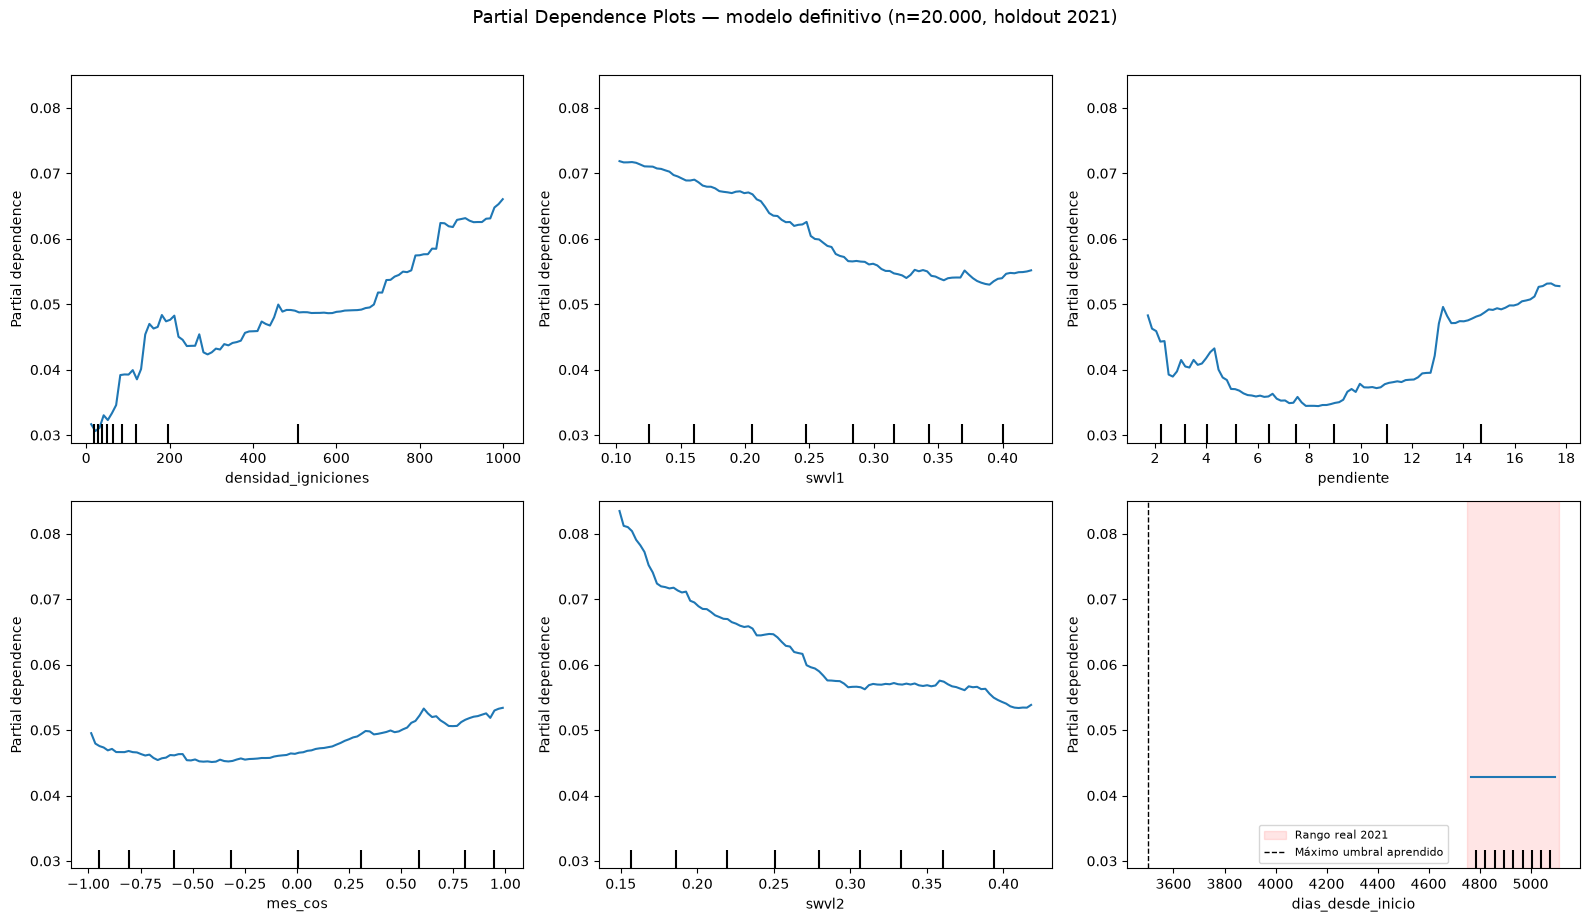

In [29]:
# ============================================================
# PDP INDIVIDUALES — VARIABLES DE SEÑAL GENUINA + CONTRASTE
# method='brute': calcula la dependencia parcial sustituyendo
# los valores de la variable analizada y promediando las
# predicciones sobre la muestra. Se utiliza sobre el modelo
# DEFINITIVO (no el proxy) para que el análisis PDP describa
# directamente el modelo utilizado como resultado del TFM.
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

PartialDependenceDisplay.from_estimator(
    modelo_rf_final,
    X_pdp,
    features=variables_pdp,
    feature_names=FEATURES_BASE,
    kind="average",
    method='brute',
    ax=axes[:len(variables_pdp)],
)

# Resaltar visualmente el rango real de 2021 en el PDP de dias_desde_inicio
idx_dias_ax = variables_pdp.index("dias_desde_inicio")
axes[idx_dias_ax].axvspan(4749, 5113, color="red", alpha=0.1, label="Rango real 2021")
axes[idx_dias_ax].axvline(3499.5, color="black", linestyle="--", linewidth=1,
                            label="Máximo umbral aprendido")
axes[idx_dias_ax].legend(fontsize=8)

plt.suptitle("Partial Dependence Plots — modelo definitivo (n=20.000, holdout 2021)",
             fontsize=13, y=1.02)
plt.tight_layout()
save_figure("pdp_variables_principales.png")
plt.show()

## PDP <=> SHAP

In [30]:
# ============================================================
# COMPARACIÓN PDP ↔ SHAP
# ============================================================

correlaciones_shap_top = []

for var in top_variables_shap:
    idx = FEATURES_BASE.index(var)

    shap_var = shap_global_positive[:, idx]
    valor_var = X_shap_global[var].values

    corr = np.corrcoef(valor_var, shap_var)[0, 1]
    correlaciones_shap_top.append(corr)

comparacion_pdp_shap = pd.DataFrame({"Variable": top_variables_shap,
        "Correlación valor-SHAP": correlaciones_shap_top,})

comparacion_pdp_shap["Dirección SHAP"] = np.where(comparacion_pdp_shap["Correlación valor-SHAP"] > 0,
        "Positiva",
        "Negativa")

print_header("COMPARACIÓN PDP vs SHAP — DIRECCIÓN DEL EFECTO")
display(comparacion_pdp_shap)

COMPARACIÓN PDP vs SHAP — DIRECCIÓN DEL EFECTO


,Variable,Correlación valor-SHAP,Dirección SHAP
0,densidad_igniciones,0.812172,Positiva
1,swvl1,-0.918293,Negativa
2,pendiente,0.571526,Positiva
3,mes_cos,-0.671237,Negativa


Cabe destacar que se comparan los patrones obtenidos mediante PDP y SHAP sobre la misma muestra de 20.000 observaciones.

SHAP procede del modelo proxy validado por su elevada similitud con el modelo definitivo, mientras que los PDP se
calculan directamente sobre el modelo definitivo. Por tanto, la comparación se interpreta como contraste de patrones, no como una comparación estrictamente idéntica entre métodos aplicados al mismo modelo.


# INTERPRETABILIDAD ESPACIAL

En esta seccion se examina si los errores del modelo (falsos negativos y falsos positivos) se concentran en  determinadas zonas geográficas, esto pudiera permitir matizar la afirmación de la introducción sobre la concentración del riesgo de incendio en el noroeste peninsular, y detectar posibles patrones espaciales del dataset shift ya documentado en el capítulo de modelado

In [31]:
# ============================================================
# PREDICCIONES Y CLASIFICACIÓN DE ERRORES — HOLDOUT 2021
#
# Se utiliza el modelo definitivo y el umbral de decisión
# determinado previamente mediante el procedimiento walk-forward,
# sin utilizar información del holdout para establecerlo.
# ============================================================

proba_holdout_completo = modelo_rf_final.predict_proba(holdout_df_test[FEATURES_BASE])[:, 1]
pred_holdout = (proba_holdout_completo >= umbral_rf_final).astype(int)

df_error = holdout_df_test[["latitude", "longitude", TARGET]].copy()
df_error["proba"] = proba_holdout_completo
df_error["prediccion"] = pred_holdout

# Clasificación inicial como verdaderos negativos
df_error["tipo"] = "TN"

# Verdaderos positivos
df_error.loc[(df_error[TARGET] == 1) & (df_error["prediccion"] == 1), "tipo"] = "TP"

# Falsos negativos
df_error.loc[(df_error[TARGET] == 1) & (df_error["prediccion"] == 0), "tipo"] = "FN"

# Falsos positivos
df_error.loc[(df_error[TARGET] == 0) & (df_error["prediccion"] == 1), "tipo"] = "FP"


# ============================================================
# RESUMEN GLOBAL DE CLASIFICACIÓN
# ============================================================

print_header("CLASIFICACIÓN DE ERRORES — HOLDOUT 2021")

print(f"Umbral utilizado: {umbral_rf_final:.4f}")
print(f"Observaciones: {len(df_error):,}")

print("\nNúmero de observaciones por tipo:")
print(
    df_error["tipo"]
    .value_counts()
    .reindex(["TN", "FP", "FN", "TP"])
    .fillna(0)
    .astype(int)
)

print("\nProporción sobre el holdout:")
print((
        df_error["tipo"]
        .value_counts(normalize=True)
        .reindex(["TN", "FP", "FN", "TP"])
        .fillna(0)
        * 100
    ).round(4)
)

CLASIFICACIÓN DE ERRORES — HOLDOUT 2021
Umbral utilizado: 0.5782
Observaciones: 298,205

Número de observaciones por tipo:
tipo
TN    296160
FP      1647
FN       336
TP        62
Name: count, dtype: int64

Proporción sobre el holdout:
tipo
TN    99.3142
FP     0.5523
FN     0.1127
TP     0.0208
Name: proportion, dtype: float64


In [32]:
# ============================================================
# DENSIDAD MUESTRAL POR CELDA
# Antes de interpretar la concentración espacial de errores,
# se cuantifica cuántas observaciones y cuántos incendios reales
# contiene cada celda.
# Esto permite distinguir:
#   - una celda con muchos errores porque tiene muchas
#     oportunidades de error;
#   - una celda con una tasa de error anormalmente elevada.
# ============================================================

estadisticas_celda = (
    df_error
    .groupby(["latitude", "longitude"])
    .agg(
        observaciones=(TARGET, "size"),
        incendios_reales=(TARGET, "sum"),
        positivos_predichos=("prediccion", "sum"),
        FN=("tipo", lambda x: (x == "FN").sum()),
        FP=("tipo", lambda x: (x == "FP").sum()),
        TP=("tipo", lambda x: (x == "TP").sum()),
        TN=("tipo", lambda x: (x == "TN").sum()),
    )
    .reset_index())

# Tasas de error
estadisticas_celda["tasa_FN"] = np.where(
    estadisticas_celda["incendios_reales"] > 0,
    estadisticas_celda["FN"] /
    estadisticas_celda["incendios_reales"],
    np.nan)

negativos_reales = (estadisticas_celda["observaciones"] - estadisticas_celda["incendios_reales"])

estadisticas_celda["negativos_reales"] = negativos_reales

estadisticas_celda["tasa_FP"] = np.where(
    negativos_reales > 0,
    estadisticas_celda["FP"] /
    negativos_reales,
    np.nan)

print_header("DENSIDAD MUESTRAL POR CELDA — HOLDOUT 2021")

print(f"Celdas observadas: {len(estadisticas_celda):,}")
print(f"Celdas con al menos un incendio real: {(estadisticas_celda['incendios_reales'] > 0).sum():,}")
print(f"Celdas con ≥3 incendios reales: {(estadisticas_celda['incendios_reales'] >= 3).sum():,}")
print(f"Celdas con ≥5 incendios reales: {(estadisticas_celda['incendios_reales'] >= 5).sum():,}")
print("\nDistribución del número de incendios por celda:")
print(estadisticas_celda.loc[estadisticas_celda["incendios_reales"] > 0, "incendios_reales"].describe())

DENSIDAD MUESTRAL POR CELDA — HOLDOUT 2021
Celdas observadas: 817
Celdas con al menos un incendio real: 82
Celdas con ≥3 incendios reales: 53
Celdas con ≥5 incendios reales: 32

Distribución del número de incendios por celda:
count    82.000000
mean      4.853659
std       4.508215
min       1.000000
25%       2.000000
50%       3.500000
75%       6.000000
max      22.000000
Name: incendios_reales, dtype: float64


## Densidad de observaciones e incendios por celda

### Falsos negativos: conteo absoluto y tasa de FN

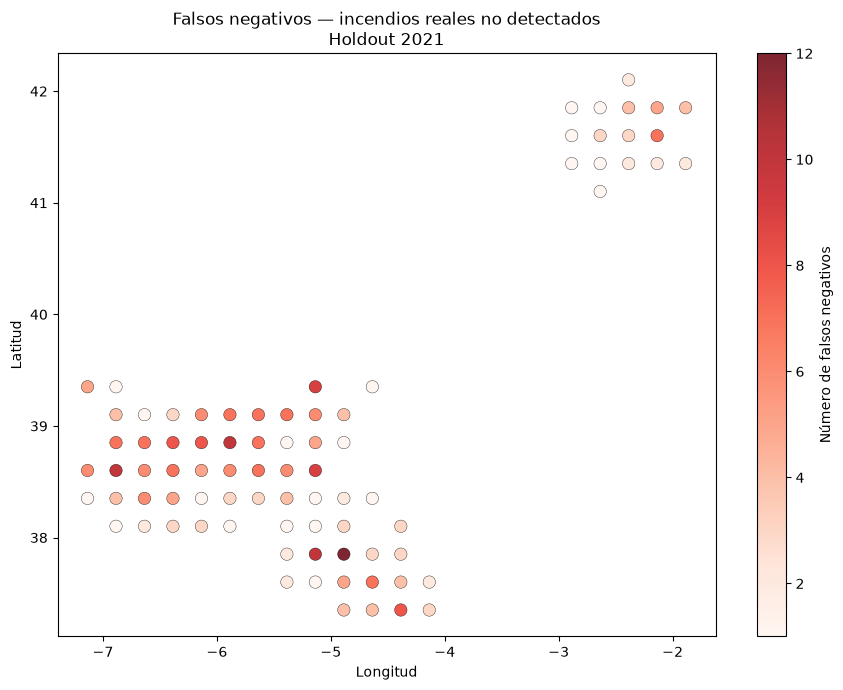

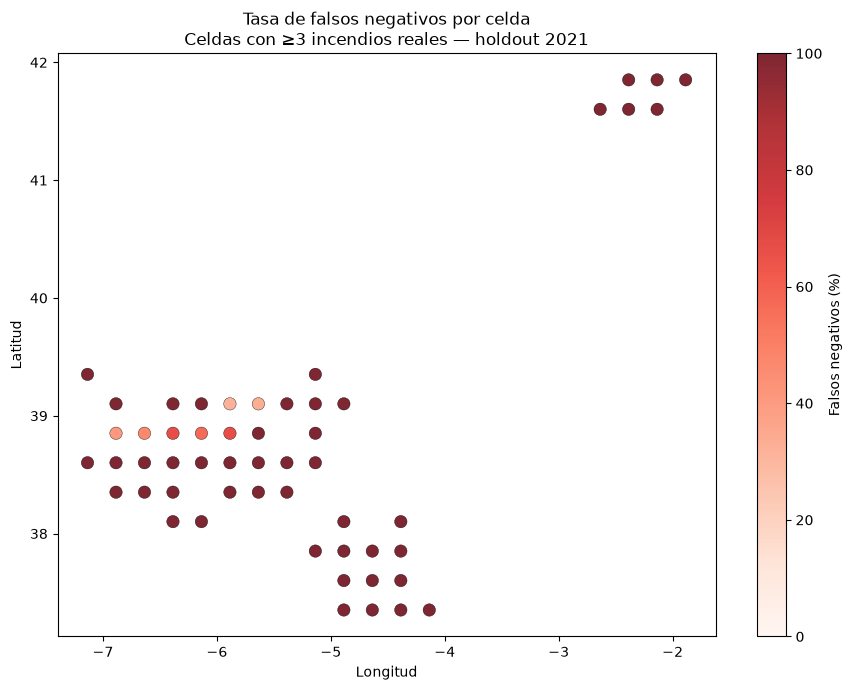

In [33]:
# ============================================================
# FALSOS NEGATIVOS — ANÁLISIS ESPACIAL
# Se presentan dos medidas:
#   1. Conteo absoluto de FN:
#      número de incendios reales que el modelo no detectó.
#   2. Tasa de FN:
#      proporción de incendios reales que fueron omitidos.
## La segunda medida es la más adecuada para comparar celdas
# con distinta frecuencia de incendios.
# ============================================================

fn_por_celda = estadisticas_celda[estadisticas_celda["FN"] > 0].copy()

# ------------------------------------------------------------
# MAPA 1 — CONTEO ABSOLUTO DE FALSOS NEGATIVOS
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(
    fn_por_celda["longitude"],
    fn_por_celda["latitude"],
    c=fn_por_celda["FN"],
    cmap="Reds",
    s=80,
    edgecolor="k",
    linewidth=0.3,
    alpha=0.85)

plt.colorbar(sc, ax=ax, label="Número de falsos negativos")
ax.set_title("Falsos negativos — incendios reales no detectados\n" "Holdout 2021")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
plt.tight_layout()
save_figure("mapa_falsos_negativos.png")
plt.show()

# ------------------------------------------------------------
# MAPA 2 — TASA DE FALSOS NEGATIVOS
# Solo se representan celdas con al menos 3 incendios reales
# para evitar tasas extremas derivadas de denominadores muy
# pequeños.
# ------------------------------------------------------------

fn_rate = estadisticas_celda[estadisticas_celda["incendios_reales"] >= 3].copy()
fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(
    fn_rate["longitude"],
    fn_rate["latitude"],
    c=fn_rate["tasa_FN"] * 100,
    cmap="Reds",
    vmin=0,
    vmax=100,
    s=80,
    edgecolor="k",
    linewidth=0.3,
    alpha=0.85)

plt.colorbar(sc, ax=ax, label="Falsos negativos (%)")
ax.set_title("Tasa de falsos negativos por celda\n" "Celdas con ≥3 incendios reales — holdout 2021")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
plt.tight_layout()
save_figure("mapa_tasa_falsos_negativos.png")
plt.show()

### Falsos positivos: conteo y tasa

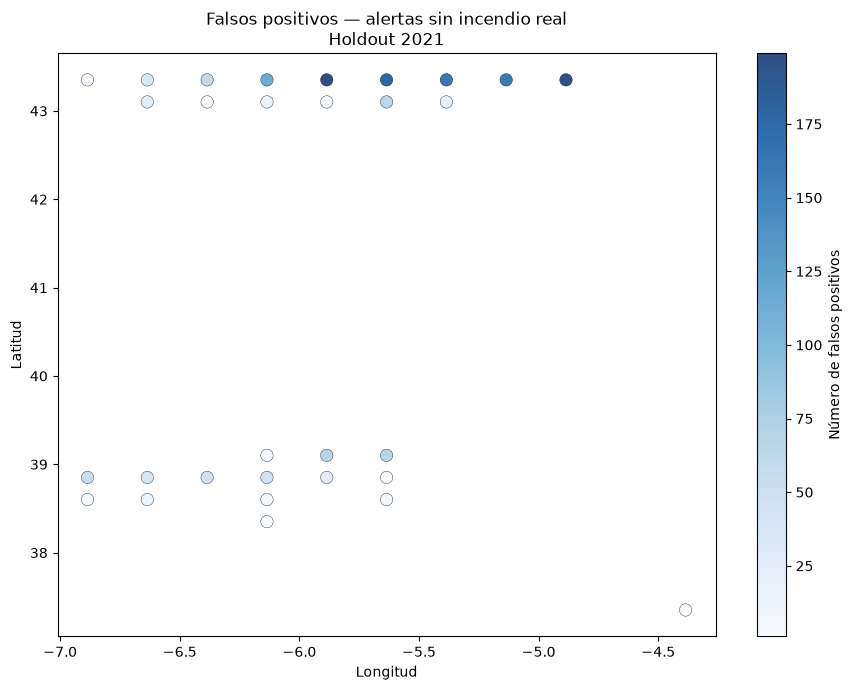

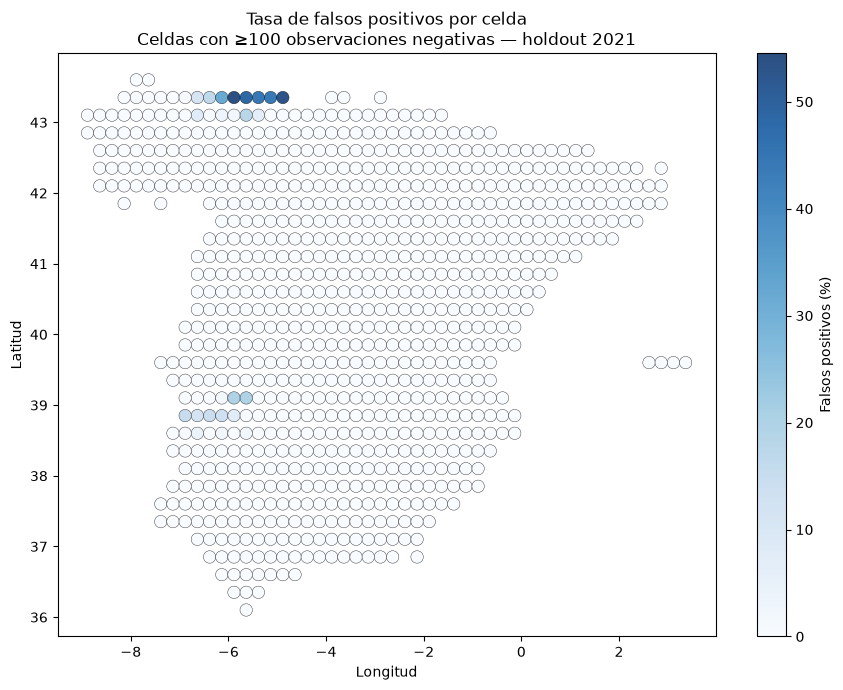

In [34]:
# ============================================================
# FALSOS POSITIVOS — ANÁLISIS ESPACIAL
# Los FP representan observaciones para las que el modelo
# genera una alerta pero no se registra incendio.
# Como ocurre con los FN, el conteo absoluto depende de la
# cantidad de observaciones disponibles en cada celda.
# Por ello se complementa con la tasa de FP sobre los negativos
# reales.
# ============================================================

# ------------------------------------------------------------
# MAPA 3 — CONTEO ABSOLUTO DE FALSOS POSITIVOS
# ------------------------------------------------------------

fp_por_celda = estadisticas_celda[estadisticas_celda["FP"] > 0].copy()
fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(
    fp_por_celda["longitude"],
    fp_por_celda["latitude"],
    c=fp_por_celda["FP"],
    cmap="Blues",
    s=80,
    edgecolor="k",
    linewidth=0.3,
    alpha=0.85)

plt.colorbar(sc, ax=ax, label="Número de falsos positivos")
ax.set_title("Falsos positivos — alertas sin incendio real\n" "Holdout 2021")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
plt.tight_layout()
save_figure("mapa_falsos_positivos.png")
plt.show()

# ------------------------------------------------------------
# MAPA 4 — TASA DE FALSOS POSITIVOS
# Se excluyen celdas con muy pocas observaciones negativas.
# ------------------------------------------------------------

fp_rate = estadisticas_celda[estadisticas_celda["negativos_reales"] >= 100].copy()
fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(
    fp_rate["longitude"],
    fp_rate["latitude"],
    c=fp_rate["tasa_FP"] * 100,
    cmap="Blues",
    s=80,
    edgecolor="k",
    linewidth=0.3,
    alpha=0.85)

plt.colorbar(sc, ax=ax, label="Falsos positivos (%)")
ax.set_title("Tasa de falsos positivos por celda\n" "Celdas con ≥100 observaciones negativas — holdout 2021")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
plt.tight_layout()
save_figure("mapa_tasa_falsos_positivos.png")
plt.show()

### Celdas con mayor concentración de errores

In [35]:
# ============================================================
# CELDAS CON MAYOR CONCENTRACIÓN DE FALSOS NEGATIVOS
# Se muestran simultáneamente:
#   - coordenadas;
#   - número de incendios reales;
#   - número de FN;
#   - tasa de FN.
# La tasa se utiliza como medida principal y el número de
# incendios como contexto.
# ============================================================

top_fn = (estadisticas_celda[estadisticas_celda["incendios_reales"] >= 3]
    .sort_values(["tasa_FN", "incendios_reales"], ascending=[False, False]).head(15))

print_header("TOP 15 CELDAS — MAYOR TASA DE FALSOS NEGATIVOS")

print(top_fn[["latitude", "longitude", "incendios_reales", "FN", "tasa_FN"]]
    .assign(tasa_FN=lambda x: x["tasa_FN"] * 100).to_string(index=False))

TOP 15 CELDAS — MAYOR TASA DE FALSOS NEGATIVOS
 latitude  longitude  incendios_reales  FN  tasa_FN
37.851418  -4.885475                12  12    100.0
37.851418  -5.135475                10  10    100.0
38.601418  -6.885475                10  10    100.0
38.601418  -5.135475                 9   9    100.0
39.351418  -5.135475                 9   9    100.0
37.351418  -4.385475                 8   8    100.0
37.601418  -4.635475                 7   7    100.0
38.601418  -6.385475                 7   7    100.0
38.601418  -5.635475                 7   7    100.0
38.851418  -5.635475                 7   7    100.0
39.101418  -5.385475                 7   7    100.0
41.601418  -2.135475                 7   7    100.0
38.351418  -6.635475                 6   6    100.0
38.601418  -7.135475                 6   6    100.0
38.601418  -6.635475                 6   6    100.0


## Contraste exploratorio

In [36]:
# ============================================================
# CONTRASTE EXPLORATORIO — NOROESTE PENINSULAR
# Se utiliza una delimitación geográfica aproximada únicamente
# como herramienta exploratoria:
#   latitud >= 42º N
#   longitud <= -4º O
# Esta delimitación NO representa una región administrativa
# oficial y no debe interpretarse como tal.
# El objetivo es comprobar si existe una concentración
# diferencial de errores en esta zona respecto al resto
# del territorio observado.
# ============================================================

df_error["zona_noroeste"] = ((df_error["latitude"] >= 42) & (df_error["longitude"] <= -4))

print_header("CONTRASTE EXPLORATORIO — NOROESTE PENINSULAR")
print(df_error["zona_noroeste"]
    .value_counts()
    .rename(index={True: "Noroeste aproximado", False: "Resto"}))

CONTRASTE EXPLORATORIO — NOROESTE PENINSULAR
zona_noroeste
Resto                  256960
Noroeste aproximado     41245
Name: count, dtype: int64


In [37]:
# ============================================================
# TASAS DE ERROR — NOROESTE vs RESTO
# ============================================================

resumen_zona = (
    df_error
    .groupby("zona_noroeste")
    .agg(
        observaciones=(TARGET, "size"),
        incendios_reales=(TARGET, "sum"),
        FN=("tipo", lambda x: (x == "FN").sum()),
        FP=("tipo", lambda x: (x == "FP").sum()),
        TP=("tipo", lambda x: (x == "TP").sum()),
        TN=("tipo", lambda x: (x == "TN").sum()),
    ))

resumen_zona["tasa_FN"] = np.where(
    resumen_zona["incendios_reales"] > 0,
    resumen_zona["FN"] /
    resumen_zona["incendios_reales"],
    np.nan)

resumen_zona["negativos_reales"] = (resumen_zona["observaciones"] - resumen_zona["incendios_reales"])

resumen_zona["tasa_FP"] = np.where(
    resumen_zona["negativos_reales"] > 0,
    resumen_zona["FP"] /
    resumen_zona["negativos_reales"],
    np.nan)

resumen_zona["sensibilidad"] = np.where(
    resumen_zona["incendios_reales"] > 0,
    resumen_zona["TP"] /
    resumen_zona["incendios_reales"],
    np.nan)

resumen_zona["precision"] = np.where(
    (resumen_zona["TP"] + resumen_zona["FP"]) > 0,
    resumen_zona["TP"] /
    (resumen_zona["TP"] + resumen_zona["FP"]),
    np.nan)

print_header("COMPARACIÓN DE RENDIMIENTO — NOROESTE vs RESTO")
tabla_zona = resumen_zona.copy()
tabla_zona.index = ["Noroeste aproximado" if x else "Resto" for x in tabla_zona.index]

display(
    tabla_zona[
        [
            "observaciones",
            "incendios_reales",
            "FN",
            "FP",
            "tasa_FN",
            "tasa_FP",
            "sensibilidad",
            "precision"
        ]
    ].style.format({
        "tasa_FN": "{:.2%}",
        "tasa_FP": "{:.2%}",
        "sensibilidad": "{:.2%}",
        "precision": "{:.2%}",
    }))

COMPARACIÓN DE RENDIMIENTO — NOROESTE vs RESTO


,observaciones,incendios_reales,FN,FP,tasa_FN,tasa_FP,sensibilidad,precision
Resto,256960,398,336,395,84.42%,0.15%,15.58%,13.57%
Noroeste aproximado,41245,0,0,1252,nan%,3.04%,nan%,0.00%


In [38]:
# ============================================================
# VERIFICACIÓN — ¿el bounding box captura la región correcta?
# ============================================================
print("Rango de coordenadas del dominio completo:")
print(f"  lat: {holdout_df_test['latitude'].min():.2f} a {holdout_df_test['latitude'].max():.2f}")
print(f"  lon: {holdout_df_test['longitude'].min():.2f} a {holdout_df_test['longitude'].max():.2f}")

print(f"\nCeldas dentro del box 'noroeste' (lat>=42, lon<=-4): "
      f"{df_error[df_error['zona_noroeste']][['latitude','longitude']].drop_duplicates().shape[0]}")
print(df_error[df_error['zona_noroeste']][['latitude','longitude']].drop_duplicates().sort_values('latitude').head(10))

Rango de coordenadas del dominio completo:
  lat: 36.10 a 43.60
  lon: -8.89 a 3.36

Celdas dentro del box 'noroeste' (lat>=42, lon<=-4): 113
      latitude  longitude
188  42.101418  -4.135475
173  42.101418  -7.885475
174  42.101418  -7.635475
175  42.101418  -7.385475
176  42.101418  -7.135475
177  42.101418  -6.885475
178  42.101418  -6.635475
179  42.101418  -6.385475
180  42.101418  -6.135475
181  42.101418  -5.885475


In [39]:
# ============================================================
# VERIFICACIÓN — ¿ES 2021 UNA ANOMALÍA GEOGRÁFICA RESPECTO AL
# HISTÓRICO EN LA ZONA NOROESTE?
# Usa dataset_maestro.parquet (03), que ya tiene el dominio y
# la definición de target consistentes con todo el proyecto.
# ============================================================

ruta_dataset_maestro = Path("data") / "dataset_maestro.parquet"  # ajustar ruta si es distinta
df_historico_completo = pd.read_parquet(ruta_dataset_maestro)
df_historico_completo["anio"] = pd.to_datetime(df_historico_completo["time"]).dt.year

zona_nw_hist = (df_historico_completo["latitude"] >= 42) & (df_historico_completo["longitude"] <= -4)

incendios_nw_por_anio = (
    df_historico_completo[zona_nw_hist]
    .groupby("anio")["target_incendio"]
    .agg(n_incendios="sum", n_dias="size")
)
incendios_nw_por_anio["prevalencia_pct"] = 100 * incendios_nw_por_anio["n_incendios"] / incendios_nw_por_anio["n_dias"]

print_header("INCENDIOS EN LA ZONA NOROESTE — POR AÑO (2008-2021)")
print(incendios_nw_por_anio)

# Comparación directa: peso relativo del NW sobre el total nacional, por año
incendios_total_por_anio = df_historico_completo.groupby("anio")["target_incendio"].sum()
peso_nw = (incendios_nw_por_anio["n_incendios"] / incendios_total_por_anio * 100).round(2)
print("\n% de incendios nacionales que ocurren en la zona NW, por año:")
print(peso_nw)

INCENDIOS EN LA ZONA NOROESTE — POR AÑO (2008-2021)
      n_incendios  n_dias  prevalencia_pct
anio                                      
2008         2865   41358         6.927318
2009         3895   41245         9.443569
2010         3069   41245         7.440902
2011         4541   41245        11.009819
2012         3859   41358         9.330722
2013         2877   41245         6.975391
2014         2016   41245         4.887865
2015         3009   41245         7.295430
2016         2210   41358         5.343585
2017         1343   41245         3.256152
2018          623   41245         1.510486
2019          686   41245         1.663232
2020          644   41358         1.557135
2021            0   41245         0.000000
2022            0     113         0.000000

% de incendios nacionales que ocurren en la zona NW, por año:
anio
2008    35.97
2009    38.02
2010    42.34
2011    44.78
2012    36.44
2013    39.14
2014    28.84
2015    36.17
2016    33.75
2017    32.53
2018    2

El noroeste concentra sistemáticamente entre el 28% y el 60% de todos los incendios nacionales cada año desde 2008 hasta 2020 incluyendo un pico del 60,13% en el propio 2020, el año inmediatamente anterior al holdout y luego, sin transición gradual, cae a 0,00% exactamente en 2021. No es una tendencia decreciente suave como la de la prevalencia nacional (que sí fue gradual, año a año) es un colapso abrupto y total, justo el año que evalúas como holdout, justo después de un año (2020) donde el NW pesaba más que nunca en la serie histórica.

In [40]:
# ============================================================
# CARGA DE CIVIO (fuente independiente) — VERIFICACIÓN CRUZADA
# Objetivo: confirmar si la ausencia de incendios en la zona NW
# durante 2021 (observada en FIRESPAIN) se replica en CIVIO, una
# fuente de datos completamente independiente
# ============================================================

civio_full = pd.read_csv(ruta_civio, parse_dates=["fecha"])
civio_full["anio"] = civio_full["fecha"].dt.year

print_header("CIVIO — CARGA EN 05_INTERPRETABILIDAD (verificación cruzada)")
print(f"Registros totales: {len(civio_full):,}")
print(f"Columnas: {list(civio_full.columns)}")
print(f"Rango de años: {civio_full['anio'].min()} - {civio_full['anio'].max()}")

CIVIO — CARGA EN 05_INTERPRETABILIDAD (verificación cruzada)
Registros totales: 292,181
Columnas: ['id', 'superficie', 'fecha', 'lat', 'lng', 'latlng_explicit', 'idcomunidad', 'idprovincia', 'idmunicipio', 'municipio', 'causa', 'causa_supuesta', 'causa_desc', 'muertos', 'heridos', 'time_ctrl', 'time_ext', 'personal', 'medios', 'gastos', 'perdidas', 'anio']
Rango de años: 1968 - 2023


In [41]:
# ============================================================
# INCENDIOS CIVIO EN LA ZONA NOROESTE — POR AÑO
# Mismo bounding box exploratorio usado en el análisis espacial:
# latitud >= 42, longitud <= -4
# Se filtran solo incendios con coordenadas válidas (exactas o
# centroide) dentro del box.
# ============================================================

civio_geo = civio_full.dropna(subset=["lat", "lng"]).copy()
zona_nw_civio = (civio_geo["lat"] >= 42) & (civio_geo["lng"] <= -4)

incendios_civio_nw_por_anio = (
    civio_geo[zona_nw_civio]
    .groupby("anio")
    .size()
    .rename("n_incendios_civio_nw")
)

print_header("CIVIO — INCENDIOS EN ZONA NOROESTE POR AÑO")
print(incendios_civio_nw_por_anio.tail(15))  # últimos años, incluyendo 2021

print(f"\nIncendios CIVIO en zona NW — 2020: "
      f"{incendios_civio_nw_por_anio.get(2020, 0):,}")
print(f"Incendios CIVIO en zona NW — 2021: "
      f"{incendios_civio_nw_por_anio.get(2021, 0):,}")

CIVIO — INCENDIOS EN ZONA NOROESTE POR AÑO
anio
2008    2337
2009    3163
2010    2361
2011    3183
2012    2929
2013    1505
2014    1358
2015    2012
2016     939
2017    2757
2018     715
2019    1659
2020    1093
2021     133
2022      84
Name: n_incendios_civio_nw, dtype: int64

Incendios CIVIO en zona NW — 2020: 1,093
Incendios CIVIO en zona NW — 2021: 133


In [42]:
# ============================================================
# ¿LOS 133 INCENDIOS CIVIO-NW-2021 SON PEQUEÑOS O TIENEN
# SUPERFICIE REGISTRADA RELEVANTE? Y ¿QUÉ % TIENE COORDENADA
# EXACTA VS CENTROIDE?
# ============================================================

civio_nw_2021 = civio_geo[(civio_geo["anio"]==2021) & zona_nw_civio[civio_geo["anio"]==2021].reindex(civio_geo.index, fill_value=False)]
# (ajustar el filtro según nombres reales de columnas de superficie/coordenadas en tu CSV)

print(civio_nw_2021[["lat","lng","fecha"]].describe())
if "latlng_explicit" in civio_full.columns:
    print(f"\n% con coordenada exacta: {100*civio_nw_2021['latlng_explicit'].mean():.1f}%")
if "loss" in civio_full.columns or "superficie" in civio_full.columns:
    col_sup = "loss" if "loss" in civio_full.columns else "superficie"
    print(f"\nSuperficie total registrada (CIVIO) NW 2021: {civio_nw_2021[col_sup].sum():,.1f}")

              lat         lng                       fecha
count  133.000000  133.000000                         133
mean    42.492509   -7.738491  2021-06-20 14:58:38.796992
min     42.003336   -9.285514         2021-01-09 00:00:00
25%     42.144113   -8.471174         2021-03-31 00:00:00
50%     42.333305   -7.947979         2021-06-12 00:00:00
75%     42.777243   -7.212097         2021-08-25 00:00:00
max     43.698864   -4.321775         2021-12-23 00:00:00
std      0.418944    1.018386                         NaN

% con coordenada exacta: 100.0%

Superficie total registrada (CIVIO) NW 2021: 1,813.2


In [43]:
# ============================================================
# ¿LOS 133 INCENDIOS CIVIO-NW-2021 CAEN EN CELDAS QUE FORMAN
# PARTE DEL DOMINIO FINAL DE MODELADO (817 celdas), O EN CELDAS
# EXCLUIDAS (fuera del bounding box de FIRESPAIN, o excluidas
# en 03 por falta de cobertura ERA5/MDT)?
# ============================================================

# Coordenadas de las 817 celdas del dominio final (las mismas de holdout_df_test)
celdas_dominio = holdout_df_test[["latitude","longitude"]].drop_duplicates().values

arbol_dominio = cKDTree(celdas_dominio)
puntos_civio = civio_nw_2021[["lat","lng"]].values  # ajustar nombre si "lat"/"lng" difiere
dist, idx = arbol_dominio.query(puntos_civio, k=1)

# Media distancia entre celdas ≈ 0.25° → si dist > 0.125° (medio paso de rejilla),
# el punto probablemente cae fuera de cualquier celda del dominio de 817
fuera_dominio = dist > 0.13

print_header("MAPEO DE LOS 133 INCENDIOS CIVIO-NW-2021 AL DOMINIO DE MODELADO")
print(f"Incendios dentro del dominio de 817 celdas : {(~fuera_dominio).sum()}")
print(f"Incendios FUERA del dominio (excluidos o fuera de FIRESPAIN): {fuera_dominio.sum()}")
print(f"\nDistancia media al centro de celda más cercano: {dist.mean():.4f}°")
print(f"Distancia máxima: {dist.max():.4f}°")

MAPEO DE LOS 133 INCENDIOS CIVIO-NW-2021 AL DOMINIO DE MODELADO
Incendios dentro del dominio de 817 celdas : 105
Incendios FUERA del dominio (excluidos o fuera de FIRESPAIN): 28

Distancia media al centro de celda más cercano: 0.1027°
Distancia máxima: 0.4045°


## ¿Los errores están espacialmente concentrados?

In [44]:
# ============================================================
# CONCENTRACIÓN ESPACIAL DE LOS ERRORES
# Se calcula qué proporción de todos los FN y FP se concentra
# en el 10% de las celdas con mayor número de errores.
# Esto permite cuantificar si los errores están relativamente
# concentrados o distribuidos de manera más homogénea.
# ============================================================

n_celdas = len(estadisticas_celda)
n_top = max(1, int(np.ceil(n_celdas * 0.10)))

# ------------------------------------------------------------
# FALSOS NEGATIVOS
# ------------------------------------------------------------

top10_fn_concentracion = (estadisticas_celda.sort_values("FN", ascending=False).head(n_top))
total_fn = estadisticas_celda["FN"].sum()
concentracion_fn = (top10_fn_concentracion["FN"].sum() / total_fn if total_fn > 0 else np.nan)

# ------------------------------------------------------------
# FALSOS POSITIVOS
# ------------------------------------------------------------

top10_fp_concentracion = (estadisticas_celda.sort_values("FP", ascending=False).head(n_top))
total_fp = estadisticas_celda["FP"].sum()
concentracion_fp = (top10_fp_concentracion["FP"].sum() / total_fp if total_fp > 0 else np.nan)

print_header("CONCENTRACIÓN ESPACIAL DE LOS ERRORES")
print(f"10% de las celdas ({n_top:,}) concentran:")
print(f"  FN: {100 * concentracion_fn:.2f}% de todos los falsos negativos")
print(f"  FP: {100 * concentracion_fp:.2f}% de todos los falsos positivos")

CONCENTRACIÓN ESPACIAL DE LOS ERRORES
10% de las celdas (82) concentran:
  FN: 100.00% de todos los falsos negativos
  FP: 100.00% de todos los falsos positivos


Referencia uniforme: si los errores estuvieran perfectamente distribuidos, el 10% de las celdas concentraría aproximadamente el 10% de los errores.

## Resumen final

In [45]:
# ============================================================
# RESUMEN FINAL — INTERPRETABILIDAD ESPACIAL
# ============================================================

print_header("SÍNTESIS — INTERPRETABILIDAD ESPACIAL")
print(f"Observaciones analizadas       : {len(df_error):,}")
print(f"Celdas espaciales              : {len(estadisticas_celda):,}")
print(f"Falsos negativos               : {total_fn:,}")
print(f"Falsos positivos               : {total_fp:,}")

print(f"\nConcentración del 10% superior de celdas:")

print(f"  FN: {100 * concentracion_fn:.2f}% de los FN")
print(f"  FP: {100 * concentracion_fp:.2f}% de los FP")
print("\nContraste exploratorio con el noroeste:")

print(tabla_zona[["observaciones", "incendios_reales", "tasa_FN", "tasa_FP", "sensibilidad"]].to_string())

SÍNTESIS — INTERPRETABILIDAD ESPACIAL
Observaciones analizadas       : 298,205
Celdas espaciales              : 817
Falsos negativos               : 336
Falsos positivos               : 1,647

Concentración del 10% superior de celdas:
  FN: 100.00% de los FN
  FP: 100.00% de los FP

Contraste exploratorio con el noroeste:
                     observaciones  incendios_reales   tasa_FN   tasa_FP  sensibilidad
Resto                       256960               398  0.844221  0.001540      0.155779
Noroeste aproximado          41245                 0       NaN  0.030355           NaN


SINTESIS GENERAL

- **SHAP:** las variables con mayor contribución interpretable fueron densidad_igniciones, swvl1, pendiente y mes_cos. El efecto de dias_desde_inicio se identificó como un artefacto asociado a la extrapolación temporal del modelo.

- **PDP:** los patrones observados son coherentes con las relaciones identificadas mediante SHAP, especialmente para la humedad del suelo y la densidad histórica de igniciones. La interacción swvl1 × mes_cos aporta evidencia de que el efecto de la humedad puede variar según la estacionalidad.

- **Interpretabilidad espacial:** el análisis de falsos negativos y falsos positivos permite comprobar si los errores presentan concentración geográfica y aporta contexto para interpretar el dataset shift observado en el holdout de 2021.

- **Conclusión general:** los métodos de interpretabilidad complementan las métricas de rendimiento y permiten identificar qué variables utiliza el modelo, cómo afectan a sus predicciones y dónde presenta mayores dificultades.

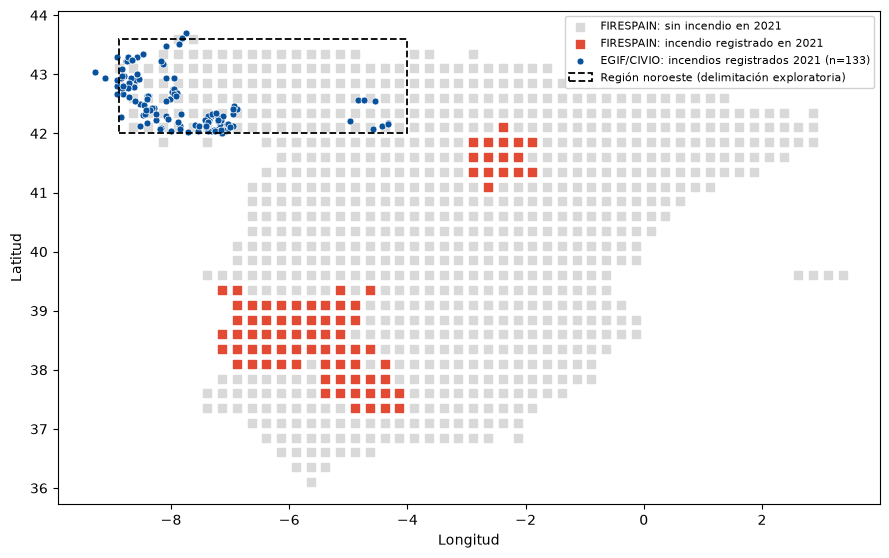

In [ ]:
# ============================================================
# MAPA — CONTRASTE FIRESPAIN-025 vs EGIF/CIVIO EN EL NOROESTE (2021)
# Figura para la memoria (sección 5.4)
# ============================================================

fig, ax = plt.subplots(figsize=(9, 8))

# --- Fondo: dominio completo de 817 celdas, coloreado según si
# FIRESPAIN registró algún incendio en 2021 (gris = no, rojo = sí) ---
celdas_dominio = holdout_df_test.groupby(["latitude", "longitude"])[TARGET].max().reset_index()

ax.scatter(
    celdas_dominio.loc[celdas_dominio[TARGET] == 0, "longitude"],
    celdas_dominio.loc[celdas_dominio[TARGET] == 0, "latitude"],
    color="#d9d9d9", s=40, marker="s", label="FIRESPAIN: sin incendio en 2021", zorder=1
)
ax.scatter(
    celdas_dominio.loc[celdas_dominio[TARGET] == 1, "longitude"],
    celdas_dominio.loc[celdas_dominio[TARGET] == 1, "latitude"],
    color="#e34a33", s=40, marker="s", label="FIRESPAIN: incendio registrado en 2021", zorder=2
)

# --- Puntos: incendios reales según CIVIO en la zona noroeste ---
ax.scatter(
    civio_nw_2021["lng"], civio_nw_2021["lat"],
    color="#08519c", s=25, marker="o", edgecolor="white", linewidth=0.5,
    label=f"EGIF/CIVIO: incendios registrados 2021 (n={len(civio_nw_2021)})", zorder=3
)

# --- Rectángulo delimitando la región noroeste (bounding box exploratorio) ---
from matplotlib.patches import Rectangle
lon_min, lon_max = celdas_dominio["longitude"].min(), -4
lat_min, lat_max = 42, celdas_dominio["latitude"].max()
ax.add_patch(Rectangle(
    (lon_min, lat_min), lon_max - lon_min, lat_max - lat_min,
    fill=False, edgecolor="black", linestyle="--", linewidth=1.3, zorder=4,
    label="Región noroeste (delimitación exploratoria)"
))

ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
ax.set_aspect("equal")

plt.tight_layout()
save_figure("mapa_contraste_firespain_civio_2021.png")
plt.show()

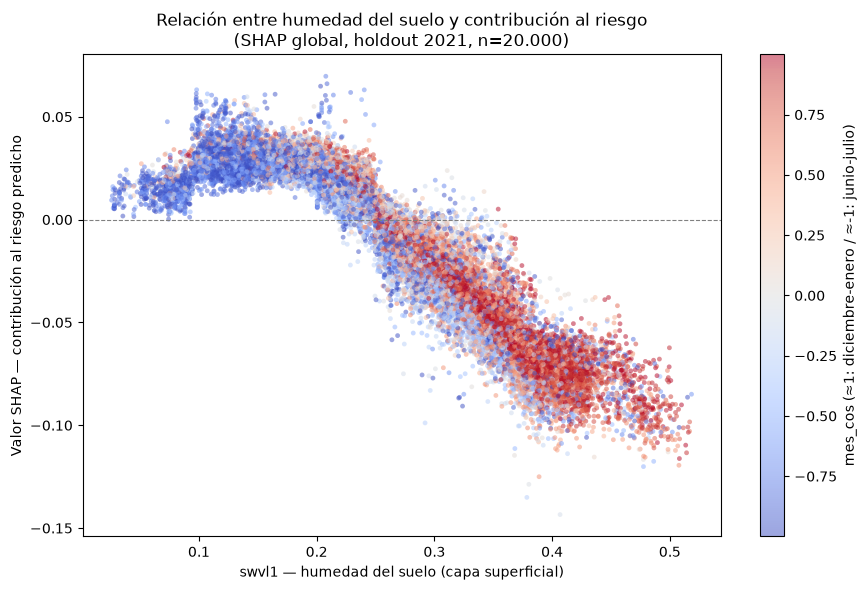

Correlación swvl1 vs SHAP: -0.9183


In [49]:
# ============================================================
# SHAP DEPENDENCE — swvl1 (humedad del suelo)
# Figura para la memoria (sección 5.4 / hipótesis del trabajo)
# ============================================================

idx_swvl1 = FEATURES_BASE.index("swvl1")
idx_mescos = FEATURES_BASE.index("mes_cos")

shap_swvl1 = shap_global_positive[:, idx_swvl1]
valor_swvl1 = X_shap_global["swvl1"].values
valor_mescos = X_shap_global["mes_cos"].values

fig, ax = plt.subplots(figsize=(9, 6))

sc = ax.scatter(
    valor_swvl1, shap_swvl1,
    c=valor_mescos, cmap="coolwarm", s=12, alpha=0.5, edgecolor="none"
)
ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("mes_cos (≈1: diciembre-enero / ≈-1: junio-julio)")

ax.set_xlabel("swvl1 — humedad del suelo (capa superficial)")
ax.set_ylabel("Valor SHAP — contribución al riesgo predicho")
ax.set_title("Relación entre humedad del suelo y contribución al riesgo\n"
              "(SHAP global, holdout 2021, n=20.000)")

plt.tight_layout()
save_figure("shap_dependence_swvl1.png")
plt.show()

# Verificación numérica de apoyo (ya calculada, se reutiliza)
corr_swvl1 = np.corrcoef(valor_swvl1, shap_swvl1)[0, 1]
print(f"Correlación swvl1 vs SHAP: {corr_swvl1:.4f}")